<!-- CNN Model for Image Classification — MNIST Digits
====================================================
This script builds, trains, and evaluates a Convolutional Neural Network
on the MNIST handwritten digit dataset (0-9).
 
Architecture:
  Input (28x28x1) → Conv2D(32) → MaxPool → Conv2D(64) → MaxPool
  → Flatten → Dense(128) → Dropout → Dense(10, softmax) -->

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('Import successful!')

TensorFlow version: 2.21.0
Import successful!


In [8]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape: CNN ko 4D chahiye
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32')  / 255.0

# One-hot encode
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)


In [9]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(28,28,1), name='conv1'),
    layers.MaxPooling2D((2,2), name='pool1'),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
    layers.MaxPooling2D((2,2), name='pool2'),

    # Fully Connected
    layers.Flatten(name='flatten'),
    layers.Dense(128, activation='relu', name='fc1'),
    layers.Dropout(0.5, name='dropout'),
    layers.Dense(10, activation='softmax', name='output')
])

model.summary()

/home/hodorinfo4/Desktop/Machine Learning/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778477372.043622   17888 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9081 - loss: 0.3029 - val_accuracy: 0.9825 - val_loss: 0.0605
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.9713 - loss: 0.0940 - val_accuracy: 0.9868 - val_loss: 0.0468
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.9792 - loss: 0.0688 - val_accuracy: 0.9897 - val_loss: 0.0364
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.9826 - loss: 0.0580 - val_accuracy: 0.9907 - val_loss: 0.0356
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9859 - loss: 0.0479 - val_accuracy: 0.9903 - val_loss: 0.0344
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9875 - loss: 0.0414 - val_accuracy: 0.9908 - val_loss: 0.0325
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9888 - loss: 0.0358 - val_accuracy: 0.9897 - val_loss: 0.0337
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.9898 - loss: 0.0324 - 

Test Accuracy: 99.24%


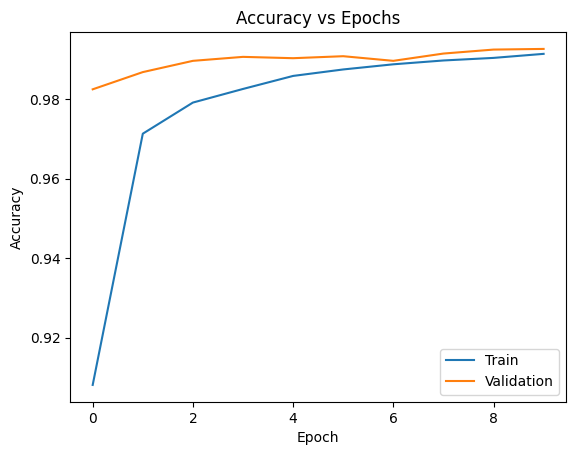

In [11]:
# Test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')

# Graph
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


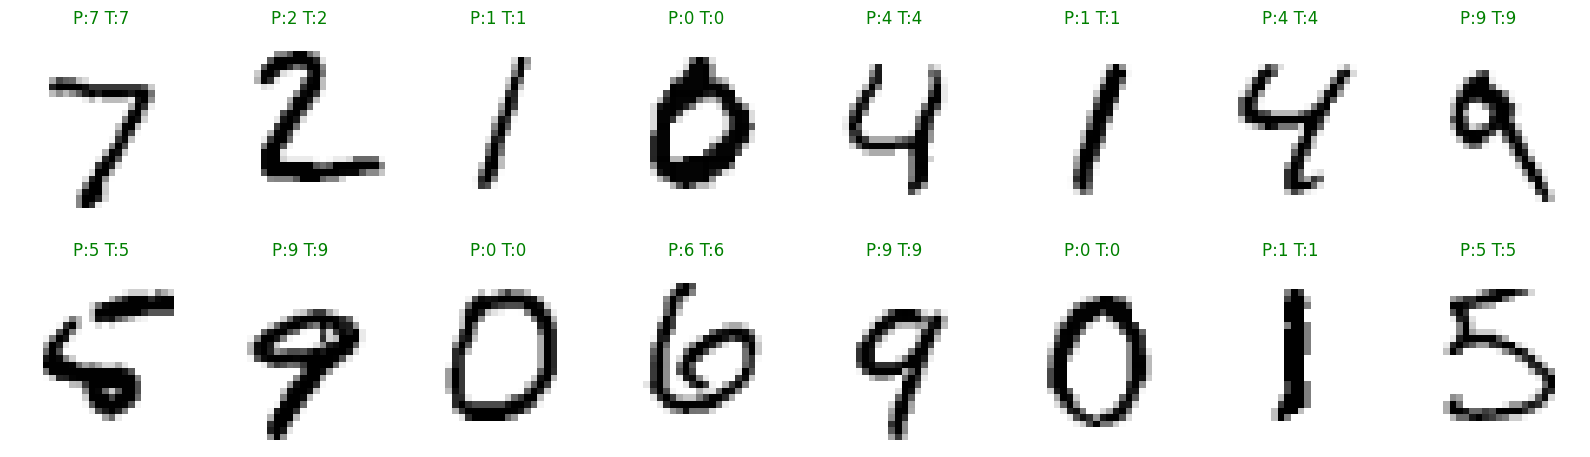

In [12]:
predictions = model.predict(x_test[:16])
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test[:16], axis=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i].reshape(28,28), cmap='gray_r')
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    ax.set_title(f'P:{pred_labels[i]} T:{true_labels[i]}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()